<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
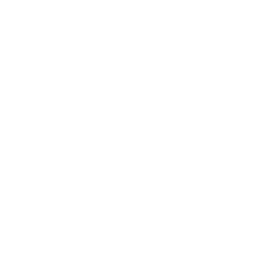
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identification des régimes de marché</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finance quantitative / Gestion d'actifs &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Cet exemple utilise **PROC ACECLUS** pour retrouver la structure latente qui sépare les régimes de marché, puis effectue un partitionnement sur celle-ci. À partir de 100 observations hebdomadaires portant sur 10 caractéristiques de marché (rendement et volatilité des actions, spreads de crédit et high-yield, la courbe 2 ans / 10 ans, le dollar, les matières premières et une variation du VIX), ACECLUS estime une covariance intra-régime approchée *sans* utiliser aucune étiquette de régime, et en dérive des variables canoniques le long desquelles les régimes s'écartent.

Au seuil P=0.02, l'algorithme converge en deux itérations et retient **trois dimensions canoniques**, qui rendent compte ensemble de la totalité de l'écart entre régimes (proportions de valeurs propres 57.8%, 24.4%, 17.8%). Un seuil P=0.05 plus lâche lisse excessivement la covariance et **réduit la structure à une seule dimension** — un rappel utile que le seuil façonne matériellement le résultat.

En injectant les trois variables canoniques dans **PROC FASTCLUS** (k=4), on obtient un classement net des 100 semaines par sévérité du stress (R² global = 0.51, pseudo F = 33.2) : un noyau calme de 62 semaines, un groupe de 22 semaines en reprise / volatilité en repli, un groupe de 12 semaines à stress élevé, et un groupe de 4 semaines en crise profonde dont les spreads high-yield atteignent en moyenne ~1 514 pb. Ces affectations sont exportées pour le conditionnement en aval du risque de portefeuille.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Observations hebdomadaires des caractéristiques de marché par classe d'actifs | 100 |
| Variables : eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

La série est générée par un processus markovien à cinq états et changement de régime (expansion haussière, fin de cycle, risk-off, crise, reprise) avec des distributions de caractéristiques conditionnelles au régime. En exécution sans licence, la table de caractéristiques est plafonnée aux 100 premières observations hebdomadaires (~2 ans) — une fenêtre à dominante haussière qui traverse aussi une courte crise et une reprise. Les rendements hebdomadaires et les variations de niveau tiennent lieu des mouvements de prix de fin de semaine ; les spreads sont en points de base et la volatilité est un indice de type VIX.


---

In [1]:
/* --------------------------------------------------------
   Generate a weekly multi-asset market history with five
   embedded regime states driven by a Markov switching
   process. This worked example runs unlicensed, so the
   feature table below is capped at the first 100 weekly
   observations (~2 years) -- a bull-dominated window
   punctuated by a short crisis and recovery.
   -------------------------------------------------------- */
DONNÉES work.market_weekly;
    APPELER streaminit(42);
    /* 5 regimes: 1=Bull, 2=Late-Cycle, 3=Risk-Off, 4=Crisis, 5=Recovery */
    TABLEAU regime_names[5] $24 _temporary_
        ('Marché haussier' 'Fin de cycle' 'Aversion au risque'
         'Crise' 'Reprise');
    RETENIR current_regime 1;
    FAIRE week_id = 1 JUSQU_À 5000;
        /* Markov regime switching */
        u = rand('uniform');
        SI current_regime = 1 ALORS FAIRE; /* Bull: long-lived */
            SI u > 0.97 ALORS current_regime = 2;
        FIN;
        SINON SI current_regime = 2 ALORS FAIRE; /* Late-cycle */
            SI u > 0.92 ALORS current_regime = 3;
        FIN;
        SINON SI current_regime = 3 ALORS FAIRE; /* Risk-off */
            SI u > 0.80 ALORS current_regime = 4;
            SINON SI u < 0.10 ALORS current_regime = 1;
        FIN;
        SINON SI current_regime = 4 ALORS FAIRE; /* Crisis: short */
            SI u > 0.75 ALORS current_regime = 5;
        FIN;
        SINON SI current_regime = 5 ALORS FAIRE; /* Recovery */
            SI u > 0.85 ALORS current_regime = 1;
        FIN;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        SI current_regime = 1 ALORS FAIRE;  /* Bull */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        FIN;
        SINON SI current_regime = 2 ALORS FAIRE;  /* Late-cycle */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        FIN;
        SINON SI current_regime = 3 ALORS FAIRE;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        FIN;
        SINON SI current_regime = 4 ALORS FAIRE;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        FIN;
        SINON FAIRE;  /* Recovery */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        FIN;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        SI week_id = 1 ALORS vix_chg = 0;
        SORTIE;
    FIN;
    SUPPRIMER u;
    RENOMMER credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
EXÉCUTER;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.33 seconds
  cpu   1.33 seconds


---

In [2]:
/* --------------------------------------------------------
   Distributions de référence des variables par régime
   -------------------------------------------------------- */
TITRE "Distributions des variables par régime";
PROCÉDURE MOYENNES DONNÉES=work.market_weekly n mean std MIN MAX;
    CLASSE regime_label;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ÉTIQUETTE regime_label="Régime de marché"
              eq_return_pct="Rendement actions (%)"
              eq_vol_idx="Indice de volatilité"
              credit_spread_bps="Spread de crédit (pb)"
              hy_spread_bps="Spread haut rendement (pb)"
              term_spread="Spread de terme"
              vix_chg="Variation VIX";
EXÉCUTER;

                                         Distributions des variables par régime                                         

                                                  The MEANS Procedure

                                Analysis Variable : eq_return_pct Rendement actions (%)

        Régime de marché            N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------
        Aversion au risque             17     -0.8447059      1.2832441     -3.3850000      1.1810000
        Crise                          12     -2.3403333      3.9436692     -8.0160000      3.7360000
        Fin de cycle                   39      0.0364359      1.9733801     -4.6010000      3.7030000
        Marché haussie                 28      0.2860000      1.0226518     -1.5980000      2.2150000
        Reprise                         4      0.0077500      1.5951747     -0.8330000      2.4000000
    


NOTE: Option TITLE changed to Distributions des variables par régime.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                         Distributions des variables par régime                                         




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


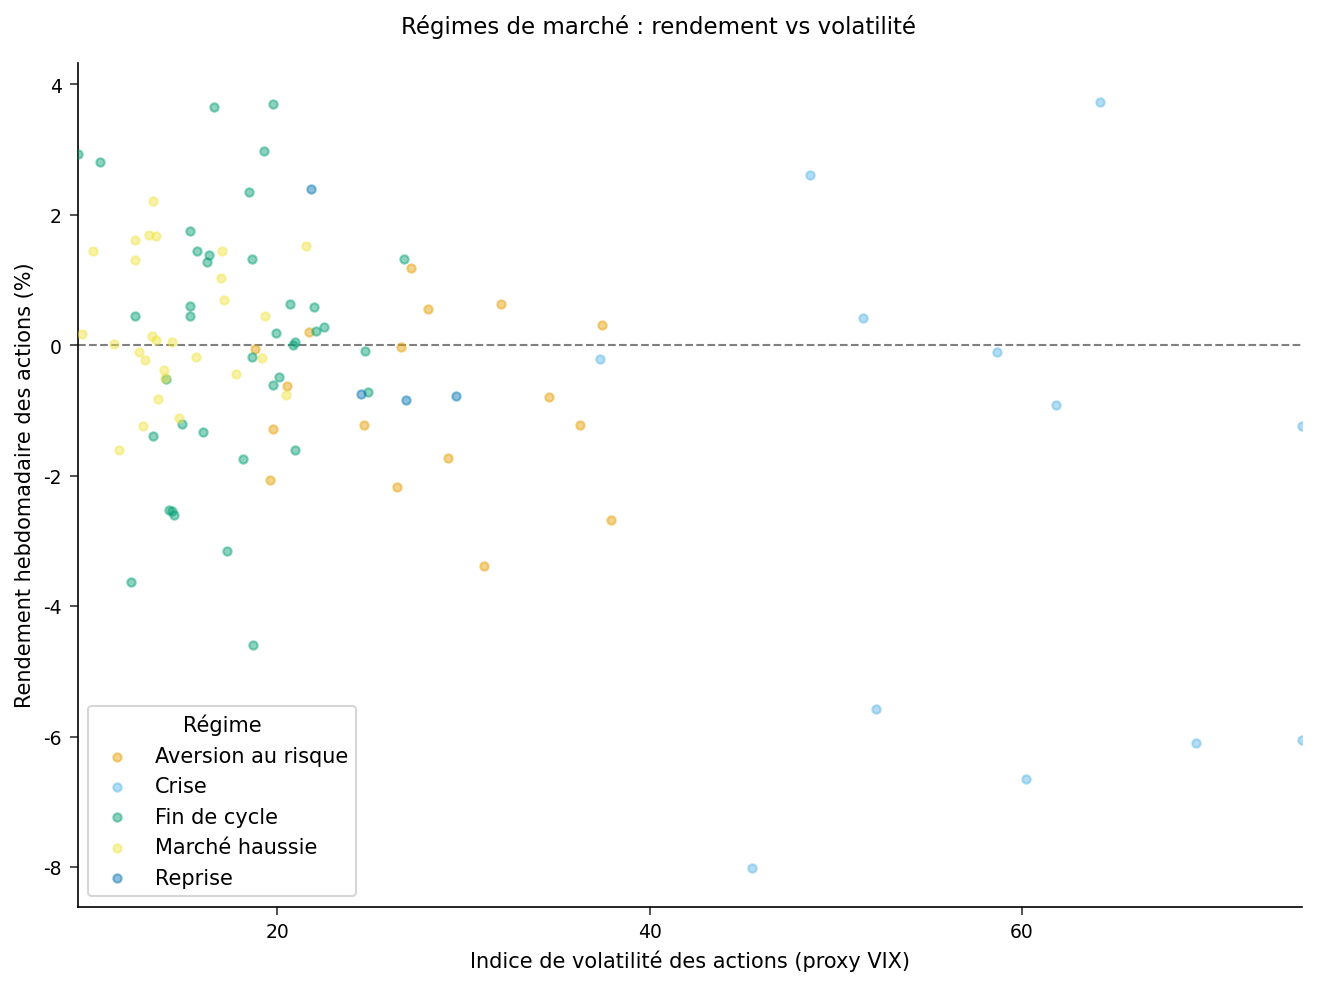

In [3]:
/* --------------------------------------------------------
   Rendement actions vs indice de volatilité par régime
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUPE=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ÉTIQUETTE="Indice de volatilité des actions (proxy VIX)";
    YAXIS ÉTIQUETTE="Rendement hebdomadaire des actions (%)";
    keylegend / TITRE="Régime";
    TITRE "Régimes de marché : rendement vs volatilité";
EXÉCUTER;

---

In [4]:
/* --------------------------------------------------------
   Estimation approchée de la covariance intra-régime.
   ACECLUS estime la covariance intra-cluster commune sans
   connaître les étiquettes de cluster, puis dérive des
   variables canoniques qui séparent les régimes. P=0.02
   fixe le seuil de distance par paires : seules les ~2%
   de paires les plus proches sont traitées comme même régime.
   -------------------------------------------------------- */
TITRE "ACECLUS — structure canonique (p=0,02)";
PROCÉDURE aceclus DONNÉES=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EXÉCUTER;

                                         ACECLUS — structure canonique (p=0,02)                                         

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: Option TITLE changed to ACECLUS — structure canonique (p=0,02).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Vérification de sensibilité à P=0.05 -- un seuil plus
   lâche tire davantage de paires, gonflant la covariance
   intra-régime estimée. Comparez la structure canonique
   (valeurs propres et dimensions retenues) à la solution P=0.02.
   -------------------------------------------------------- */
TITRE "ACECLUS — sensibilité (p=0,05)";
PROCÉDURE aceclus DONNÉES=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VAR eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
EXÉCUTER;

                                             ACECLUS — sensibilité (p=0,05)                                             

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.


NOTE: Option TITLE changed to ACECLUS — sensibilité (p=0,05).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-moyennes sur les variables canoniques ACECLUS. ACECLUS
   a retenu trois dimensions canoniques (Can1-Can3), donc le
   clustering porte sur celles-ci. Quatre clusters ciblent
   les quatre états de marché bien peuplés.
   -------------------------------------------------------- */
TITRE "k-moyennes sur les variables canoniques";
PROCÉDURE FASTCLUS DONNÉES=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VAR can1 can2 can3;
EXÉCUTER;

                                        k-moyennes sur les variables canoniques                                         


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: Option TITLE changed to k-moyennes sur les variables canoniques.
NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                            Grappe de régime vs régime réel                                             

                                                   The FREQ Procedure

Table of Grappe by Régime de marché

Grappe |Aversion au risque |             Crise |      Fin de cycle |    Marché haussie |           Reprise |              Total
-------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
1      |                 4 |                 4 |                 2 |                 2 |                 0 |                 12
       |              4.00 |              4.00 |              2.00 |              2.00 |              0.00 |              12.00
-------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
2      |                 7 |                 3 |                28 |                21 |                 3 |                 62
  


NOTE: Option TITLE changed to Grappe de régime vs régime réel.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


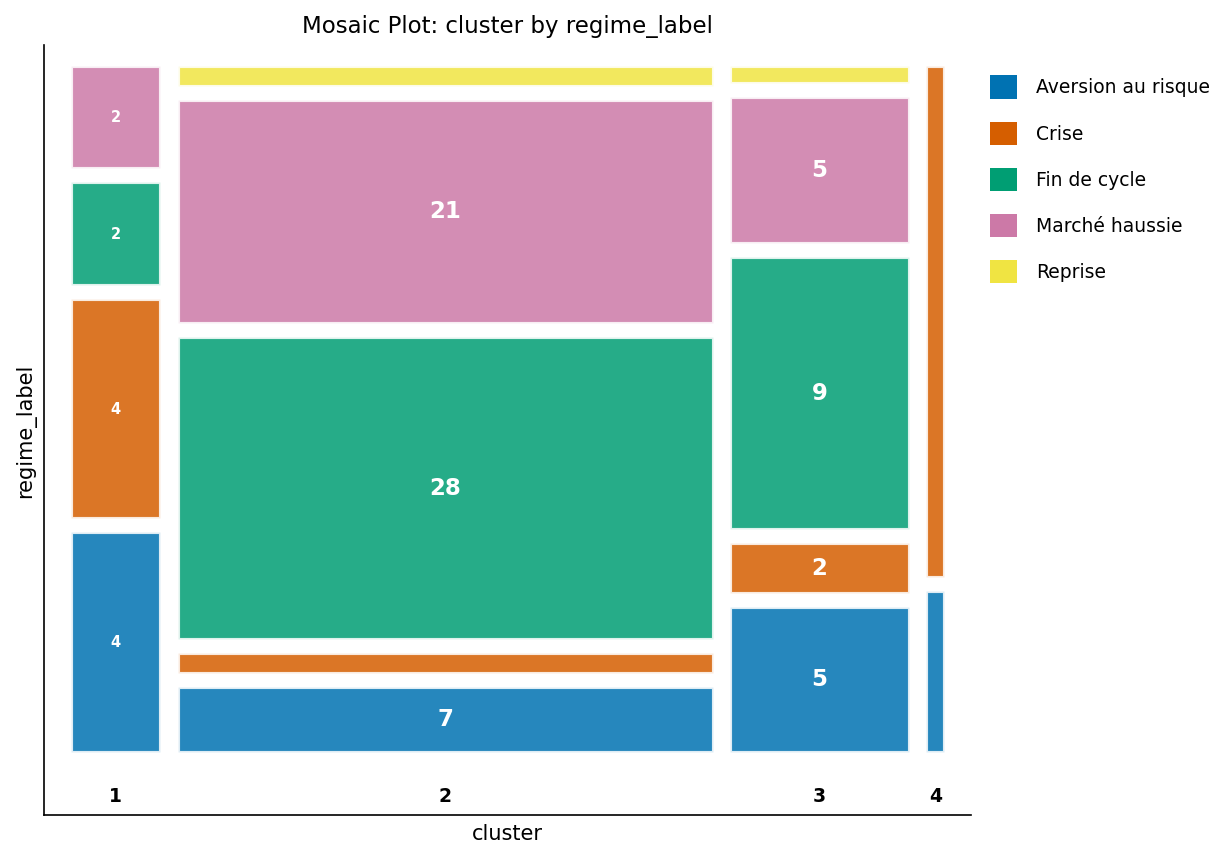

In [7]:
/* --------------------------------------------------------
   Validation des clusters attribués face aux étiquettes
   de régime connues de la génération des données
   -------------------------------------------------------- */
TITRE "Grappe de régime vs régime réel";
PROCÉDURE FRÉQUENCES DONNÉES=work.regime_assignments;
    TABLES cluster * regime_label / norow nocol;
    ÉTIQUETTE cluster="Grappe" regime_label="Régime de marché";
EXÉCUTER;

In [8]:
/* --------------------------------------------------------
   Profil des moyennes de variables par grappe (interprétation)
   -------------------------------------------------------- */
TITRE "Profil des moyennes par grappe";
PROCÉDURE MOYENNES DONNÉES=work.regime_assignments mean;
    CLASSE cluster;
    VAR eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ÉTIQUETTE cluster="Grappe"
              eq_return_pct="Rendement actions (%)"
              eq_vol_idx="Indice de volatilité"
              credit_spread_bps="Spread de crédit (pb)"
              hy_spread_bps="Spread haut rendement (pb)"
              term_spread="Spread de terme"
              vix_chg="Variation VIX";
EXÉCUTER;

                                             Profil des moyennes par grappe                                             

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Rendement actions (%)

                                                         N
                                             Grappe    Obs            Mean
                                             -----------------------------
                                             1          12      -2.0955000
                                             2          62      -0.3638871
                                             3          22       0.7421364
                                             4           4      -0.4010000
                                             -----------------------------

                                             Analysis Variable : eq_vol_idx Indice de volatilité

                      


NOTE: Option TITLE changed to Profil des moyennes par grappe.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interprétation

**Structure canonique ACECLUS.** Sur l'échantillon de 100 semaines, PROC ACECLUS (P=0.02, seuil = 2.578941) a convergé en deux itérations et produit trois variables canoniques. Leurs valeurs propres de `Inv(ACE)*(COV-ACE)` sont 0.0219, 0.0093 et 0.0067, soit des proportions de 57.8%, 24.4% et 17.8% (cumul 100%). Le premier axe canonique porte le contraste dominant risk-on / risk-off ; les deuxième et troisième l'affinent. Comme les caractéristiques de volatilité des actions et de spreads comovent fortement, ACECLUS replie cette variation partagée dans la covariance intra-régime, de sorte que les axes canoniques reflètent une véritable séparation entre régimes plutôt qu'une échelle commune.

**Sensibilité au seuil.** Ré-exécuter à P=0.05 porte le seuil de distance à 2.899704, ce qui tire 4 949 des 4 950 paires d'observations à l'intérieur de la coupure. La covariance intra-régime estimée devient alors presque égale à la covariance totale, et la structure canonique **se réduit à une seule dimension** (une valeur propre, 0.0096, à 100%). Les solutions P=0.02 et P=0.05 ne sont donc *pas* interchangeables ici — un seuil plus lâche efface les axes de régime les plus fins, si bien que le seuil plus serré est la spécification la plus informative pour cet échantillon.

**Partitionnement sur les variables canoniques.** PROC FASTCLUS (k=4) sur Can1–Can3 donne un R² global de 0.5089 et un pseudo F de 33.16. Can2 réalise l'essentiel de la séparation (R² = 0.626), Can1 contribue modérément (R² = 0.359), et Can3 n'ajoute quasiment rien (R² = 0.000) — cohérent avec le fait que seuls deux axes portent un signal fort. Les quatre clusters s'alignent en un gradient de stress de marché :

| Cluster | n | Rendement act. moyen | VIX moyen | Spread HY moyen | Variation VIX moyenne | Lecture |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 pb | +1.2 | Noyau calme (haussier / fin de cycle) |
| 3 | 22 | +0.74% | 20.5 | 539 pb | -9.6 | Reprise, volatilité en baisse |
| 1 | 12 | -2.10% | 39.0 | 720 pb | +11.3 | Stress élevé, volatilité en flambée |
| 4 |  4 | -0.40% | 47.4 | 1 514 pb | +0.1 | Crise profonde, stress de crédit extrême |

**Cluster vs. régime réel.** Le tableau croisé montre que les clusters ne correspondent pas un à un aux cinq étiquettes génératrices — attendu, car les étiquettes se recouvrent fortement dans l'espace des caractéristiques à cette taille d'échantillon. Le grand cluster calme (62) absorbe la plupart des semaines haussières (21) et de fin de cycle (28) ; le cluster de crise profonde (4) est presque entièrement composé des semaines de crise les plus extrêmes (3 sur 4). Les axes canoniques organisent ainsi les semaines par *sévérité*, et non par étiquette exacte, ce qui est le signal le plus exploitable pour le conditionnement du risque.

**Usage.** Les affectations hebdomadaires exportées soutiennent un conditionnement tactique : alléger le risque et allonger la duration à mesure que les semaines migrent vers les clusters 1 et 4, et re-risquer lorsqu'elles reviennent vers le noyau calme (cluster 2) ou le groupe en reprise (cluster 3).


---

In [9]:
/* --------------------------------------------------------
   Export des attributions hebdomadaires de régime pour le
   conditionnement du modèle de risque de portefeuille
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>